# Heart Disease Prediction using Random Forest


* In this project, I address a **classification task** focused on predicting heart disease based on clinical patient data. The goal is to design and evaluate a model that can reliably distinguish between patients with heart disease and healthy individuals.
* The solution includes a data preprocessing pipeline, feature transformations, and hyperparameter tuning for several models.
* Training data is provided in `data.csv` and evaluation data in `evaluation.csv`.

#### Feature List:

* Age: patient's age [years]
* Sex: patient's sex [M: Male, F: Female]
* Chest Pain Type: type of chest pain [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
* Resting BP: resting blood pressure [mm Hg]
* Cholesterol: serum cholesterol [mm/dl]
* Fasting BS: fasting blood sugar [1: if FastingBs > 120 mg/dl, 0: otherwise]
* Resting ECG: resting electrocardiogram results
[Normal, ST: ST-T wave abnormality, LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria].
* Max HR: maximum heart rate achieved [numeric value between 60 and 202]
* Exercise Angina: exercise-induced angina [Y: Yes, N: No]
* Old peak: ST depression induced by exercise relative to rest [numeric value]
* ST _Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
* Heart Disease: **target variable** [1: heart disease, 0: normal]

## Methodology
  * We will load data from `data.csv`. Due to the **small sample size**, we will not split the data into standard training, validation, and test sets; instead, we will utilize **cross-validation**.
  * **Basic Preprocessing**:
    * Review individual features and transform them into a format suitable for the selected classification models.
  * **Random Forest Implementation**: We will create our own custom implementation of the Random Forest algorithm.
  * Model Application: We will apply the custom Random Forest, along with **Decision Tree** and **K-Nearest Neighbors (KNN)** models:
    * Experiment with normalization if beneficial for the specific model.
    * Select and tune key hyperparameters to find their optimal values.
  * **Evaluation**: We will select the final model from the tested options and estimate the **accuracy** to be expected on new, unseen data.
  * **Final Step**: Use the model to predict patient outcomes from the `evaluation.csv` file.

### Data Insights and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay

from pandas import CategoricalDtype

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 23

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.info()

(734, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    object 
 3   ChestPainType   734 non-null    object 
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    object 
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    object 
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    object 
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 74.7+ KB


The dataset contains **734 data points** and **13 features**, with Heart Disease being the target variable.

,count
Cholesterol,
0,144
204,9
230,8
216,8
211,8
...,...
185,1
468,1
279,1


,count
Sex,
M,575
F,159


,count
ChestPainType,
ASY,392
NAP,163
ATA,140
TA,39


,count
RestingECG,
Normal,433
LVH,153
ST,148


,count
ExerciseAngina,
N,434
Y,300


,count
ST_Slope,
Flat,361
Up,319
Down,54


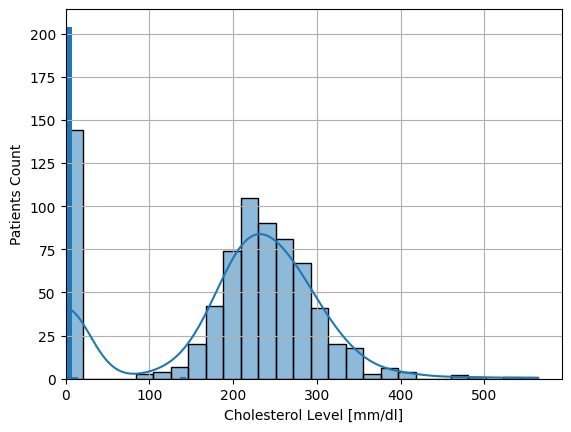

In [3]:
fig, ax = plt.subplots()
sns.histplot(ax=ax, data=df["Cholesterol"], kde=True)
ax.set_xlim(left = 0)
ax.set_xlabel("Cholesterol Level [mm/dl]")
ax.set_ylabel("Patients Count")
df["Cholesterol"].value_counts().hist(bins=20)
display(pd.DataFrame(df["Cholesterol"].value_counts()))
display(pd.DataFrame(df["Sex"].value_counts()))
display(pd.DataFrame(df["ChestPainType"].value_counts()))
display(pd.DataFrame(df["RestingECG"].value_counts()))
display(pd.DataFrame(df["ExerciseAngina"].value_counts()))
display(pd.DataFrame(df["ST_Slope"].value_counts()))

We have 5 features of type object and one particularly interesting feature: **Cholesterol**. While most cholesterol values are in the triple digits and appear to follow a normal distribution, there is a suspiciously high frequency of zeros. This is a clear indicator of missing data. We will impute these missing values using the **median** of the training set.

The **Sex** and **ExerciseAngina** features are binary, so we will convert them to 0 and 1. The **ChestPainType**, **RestingECG**, and **ST_Slope** features are categorical and will be processed using **One-Hot Encoding**.

As for the **Oldpeak** feature, it also shows a high number of zeros; however, since the non-zero values are typically in the lower single digits, we cannot say with certainty whether these zeros represent missing data or actual clinical measurements.

In [4]:
sex_cat = CategoricalDtype(categories=["M", "F"], ordered=True)
df["Sex"] = df["Sex"].astype(sex_cat)
df["Sex"] = df["Sex"].cat.codes

exe_ang_cat = CategoricalDtype(categories=["N", "Y"], ordered=True)
df["ExerciseAngina"] = df["ExerciseAngina"].astype(exe_ang_cat)
df["ExerciseAngina"] = df["ExerciseAngina"].cat.codes

In [5]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
# The median calculated from the training set must not be contaminated by zeros...
# These values are calculated from the training set after the dataset split.

In [6]:
# We assume that no new categories will appear in future datasets.
df["ChestPainType"] = df["ChestPainType"].astype("category")
df["RestingECG"] = df["RestingECG"].astype("category")
df["ST_Slope"] = df["ST_Slope"].astype("category")


In [7]:
df = pd.get_dummies(df)

#### Validation Strategy
Due to the limited size of the dataset (734 samples), I have decided to use **cross-validation** to ensure more reliable performance estimates.

In [8]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(columns=["HeartDisease"]), df["HeartDisease"], test_size=0.2, train_size=0.8, random_state=RANDOM_STATE)

In [9]:
chol_mean = Xtrain["Cholesterol"].mean()
Xtrain["Cholesterol"] = Xtrain["Cholesterol"].fillna(chol_mean)
Xtest["Cholesterol"] = Xtest["Cholesterol"].fillna(chol_mean)

### Preparing the Random Forest Model

In [10]:

class CustomRandomForest:

    def __init__(self, n_estimators, max_samples, max_depth):
        self.estimators = [DTC(max_depth = max_depth, random_state=RANDOM_STATE+i) for i in range(n_estimators)]
        self.max_samples = max_samples


    def fit(self, X, y):
        for i, estimator in enumerate(self.estimators):
            merged = pd.DataFrame(pd.concat([X, y], axis=1))

            # We ensure that each model in the ensemble has a unique data split
            # (using random_state + i) and that sampling with replacement (bootstrapping) is enabled.
            subset = merged.sample(frac=self.max_samples, random_state=RANDOM_STATE + i, replace = True)
            Xsubset = subset[X.columns]
            ysubset = subset[y.name]
            estimator.fit(Xsubset, ysubset)


    def predict(self, X):
        ypredicted = self.predict_proba(X)
        ypredicted = (ypredicted >= (0.5)).astype(int)

        return ypredicted

    def predict_proba(self, X):
        yproba = np.zeros((X.shape[0],))
        for i, estimator in enumerate(self.estimators):
            yproba += estimator.predict(X)
        yproba /= len(self.estimators)

        # Returning the arithmetic mean of the predictions from all individual trees.
        return yproba


### Hyperparameter Tuning for Random Forest
Now we will find the optimal hyperparameters for our `CustomRandomForest` using the cross-validation method mentioned earlier. Since this process is computationally expensive—much like the Random Forest algorithm itself—we cannot afford to test an exhaustive number of hyperparameter combinations. We will start with a selection and then determine if further experimentation is necessary.

In [11]:

def find_hyper_param_crf(param_comb):
    best_acc = 0
    best_params = None

    kf = KFold(n_splits = 5)
    for params in param_comb:
        fold_acc = []
        for train_index, val_index in (kf.split(Xtrain)):
            tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
            ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
            clf = CustomRandomForest(**params)
            clf.fit(tX_train, ty_train)
            fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
        acc = np.mean(fold_acc)
        if acc > best_acc:
            best_acc = acc
            best_params = params
    return best_acc, best_params

param_grid = {
    "n_estimators": [5, 10, 15, 20, 30],
    "max_samples": np.linspace(0.3, 1.2, 5),
    "max_depth": range(1, 15, 2),
}
param_comb = ParameterGrid(param_grid)
best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)
crf_best = CustomRandomForest(**best_params)
crf_best.fit(Xtrain, ytrain)

Best accuracy: 0.8688396349413299 with params: {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 30}


#### Tuning Results
The results indicate that a value of 30 for the number of estimators is at the upper limit of our current range. Consequently, we will experiment with a **higher number of trees**.

In [12]:
param_grid = {
    "n_estimators": [40, 55, 80],
    "max_samples": np.linspace(0.3, 1.2, 5),
    "max_depth": range(1, 15, 2),
}
param_comb = ParameterGrid(param_grid)

best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)


Best accuracy: 0.8688396349413299 with params: {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 40}


In [13]:
param_grid = {
    "n_estimators": [1000],
    "max_samples": np.linspace(0.2, 0.6, 3),
    "max_depth": range(4, 15, 2),
}
param_comb = ParameterGrid(param_grid)

best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)


Best accuracy: 0.858597711140084 with params: {'max_depth': 6, 'max_samples': np.float64(0.4), 'n_estimators': 1000}


We achieved the best result (0.869) with the following parameters:
 - {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 30}


### Hyperparameter Tuning for Decision Tree and KNN
Now, let's test two additional models from scikit-learn: the **Decision Tree** and the **K-Nearest Neighbors (KNN)** method. While Decision Trees are favored for their simplicity and high interpretability, KNN operates on the principle of patient similarity. This can be particularly valuable in a clinical setting - when assessing a specific patient, the outcomes of the most similar historical cases can provide the most meaningful insights.

In [14]:
### Decision Tree
best_acc = 0
best_params = None

param_grid = {
    'max_depth': range(1,31),
    'criterion': ['entropy', 'gini']
}
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):
        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
        clf = DTC(**params, random_state=RANDOM_STATE)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params

print("Best accuracy:", best_acc, "with params:", best_params)
dt_best = DTC(**best_params)
dt_best.fit(Xtrain, ytrain);

Best accuracy: 0.8348109517601043 with params: {'criterion': 'entropy', 'max_depth': 4}


In [15]:
### N-Nearest Neighbors
param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
best_acc = 0
best_params = None
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):
        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
        clf = KNeighborsClassifier(**params)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params
print("Best accuracy:", best_acc, "with params:", best_params)

Best accuracy: 0.6970013037809648 with params: {'metric': 'minkowski', 'n_neighbors': 13, 'p': 1, 'weights': 'distance'}


The KNN model is highly sensitive to feature scaling, which explains why we are currently seeing significantly worse results compared to the previous models. The data must be scaled before this model can perform effectively.

In [16]:
param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
best_acc = 0
best_params = None
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):

        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]

        scaler = StandardScaler()
        tX_train = scaler.fit_transform(tX_train)
        tX_val = scaler.transform(tX_val)

        clf = KNeighborsClassifier(**params)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params

knn_scaler = StandardScaler()
knn_X_train = knn_scaler.fit_transform(Xtrain)
knn_X_test = knn_scaler.transform(Xtest)

knn_best = KNeighborsClassifier(**best_params)
knn_best.fit(knn_X_train, ytrain)
print("Best accuracy:", best_acc, "with params:", best_params)

Best accuracy: 0.8721570331739823 with params: {'metric': 'minkowski', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}


In terms of accuracy, KNN actually performed slightly better than the Random Forest, coming in quite close at **0.872**. However, the difference between the two is minimal.

### Plotting ROC Curves and F1 Scores
We will now plot ROC curves and calculate F1 scores for each of the best-performing models.

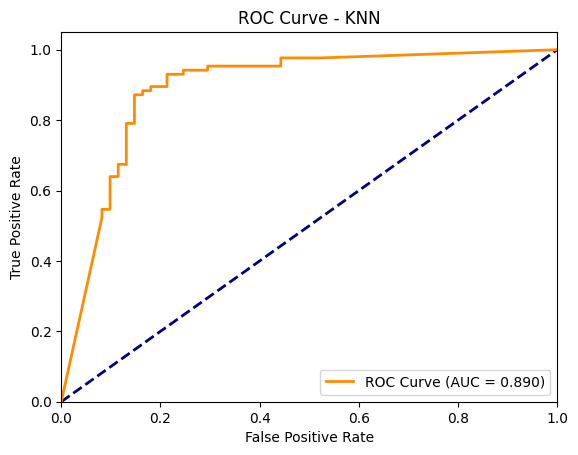

F1 score 	- KNN : 0.8771929824561403
AUC 		- KNN : 0.8904879908501715


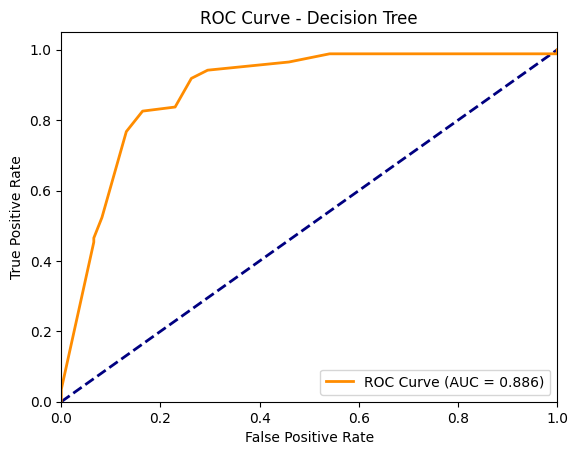

F1 score 	- Decision Tree : 0.8372093023255814
AUC 		- Decision Tree : 0.8858177659168891


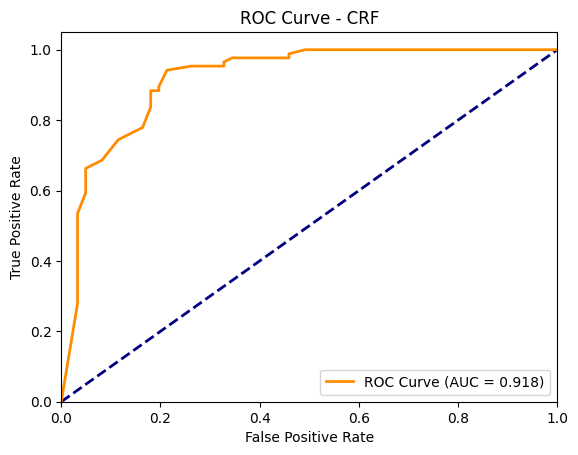

F1 score 	- CRF : 0.8913043478260869
AUC 		- CRF : 0.9175562333206252


In [17]:
def metrics_and_f1(y, yprob, ypred, title):
    AUC = roc_auc_score(y, yprob)
    fpr, tpr, thresholds = roc_curve(y, yprob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC Curve (AUC = {AUC:.3f})")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - " + title)
    plt.legend(loc="lower right")
    plt.show()
    print("F1 score \t-", title, ":" , f1_score(y, ypred))
    print("AUC \t\t-", title, ":", AUC)

y_prob_knn = knn_best.predict_proba(knn_X_test)[:, 1]
y_pred_knn = knn_best.predict(knn_X_test)
metrics_and_f1(ytest, y_prob_knn, y_pred_knn, "KNN")

y_prob_dt = dt_best.predict_proba(Xtest)[:, 1]
y_pred_dt = dt_best.predict(Xtest)
metrics_and_f1(ytest, y_prob_dt, y_pred_dt, "Decision Tree")

y_prob_crf = crf_best.predict_proba(Xtest)
y_pred_crf = crf_best.predict(Xtest)
metrics_and_f1(ytest, y_prob_crf, y_pred_crf, "CRF")


The **Random Forest** model achieves the highest **AUC (0.918)** of the three candidates, which measures the model's ability to distinguish between classes across various decision thresholds. It also boasts the highest **F1 score**, a metric that is particularly valuable when dealing with potential class imbalance. Furthermore, in medical modeling, it is much more critical to **minimize false negative predictions**; these metrics better capture the model's behavior in scenarios where missing a diagnosis is the primary concern.

### Expected Accuracy on the Test Set

In [18]:
expected_accuracy = metrics.accuracy_score(ytest, crf_best.predict(Xtest))
print("Expected accuracy:", expected_accuracy)

Expected accuracy: 0.8639455782312925


The expected accuracy on the test data is approximately **86.4%**

We will also examine the **Confusion Matrix** to evaluate the frequency of false positive versus false negative predictions:

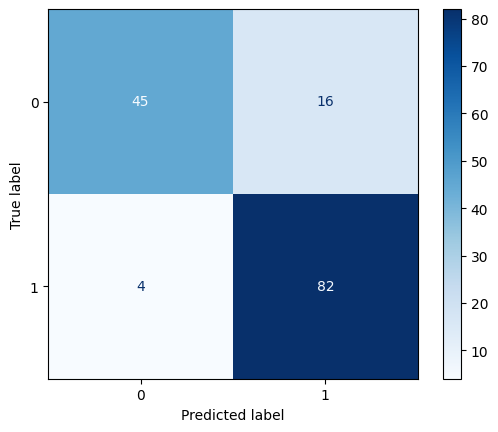

              precision    recall  f1-score   support

           0       0.92      0.74      0.82        61
           1       0.84      0.95      0.89        86

    accuracy                           0.86       147
   macro avg       0.88      0.85      0.85       147
weighted avg       0.87      0.86      0.86       147



In [19]:
ConfusionMatrixDisplay.from_predictions(ytest, crf_best.predict(Xtest),cmap='Blues')
plt.show()
from sklearn.metrics import classification_report
print(classification_report(ytest, crf_best.predict(Xtest)))

Our model exhibits a **higher recall than precision** for disease detection. This means it reliably captures the majority of sick patients, even at the cost of a higher number of false positive predictions. In a medical context, this is a highly appropriate and preferred approach.

### Evaluation of evaluation.csv with CustomRandomForrest

In [20]:
eval = pd.read_csv("evaluation.csv")


eval["ChestPainType"] = eval["ChestPainType"].astype("category")
eval["RestingECG"] = eval["RestingECG"].astype("category")
eval["ST_Slope"] = eval["ST_Slope"].astype("category")

eval["ExerciseAngina"] = eval["ExerciseAngina"].astype(exe_ang_cat)
eval["ExerciseAngina"] = eval["ExerciseAngina"].cat.codes

eval["Sex"] = eval["Sex"].astype(sex_cat)
eval["Sex"] = eval["Sex"].cat.codes

eval["Cholesterol"] = eval["Cholesterol"].replace(0, chol_mean)


In [21]:
eval = pd.get_dummies(eval)
yeval = pd.DataFrame(crf_best.predict(eval))
evalids = eval["ID"]

In [22]:
result = pd.concat([evalids, yeval], axis=1, )
result.columns = ["ID", "HeartDisease"]
result.to_csv("results.csv",index=False)

### Conclusion
The **Random Forest** model delivered the best results, outperforming both the Decision Tree and KNN in terms of AUC and F1 score. A detailed analysis of the metrics revealed that the model achieves a **high recall (0.95)** for disease detection. This signifies a very low number of false negative cases, which is the primary objective from a clinical standpoint. On the other hand, the model generates more false positives, which is considered an acceptable trade-off.